In [1]:
import pickle
import json
import os
import re
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import skimage
import tifffile
import yaml
from ome_types import from_tiff, from_xml
from matplotlib.collections import PolyCollection
from matplotlib.colors import TwoSlopeNorm
from einops import rearrange, repeat
from pydantic_extra_types.color import Color

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [3]:
def alter_filesystem(config, source_root, target_root):
    for entry in config['sections']:
        for mapping in entry['data']:
            mapping['filepath'] = mapping['filepath'].replace(source_root, target_root)
        
    return config

source_root = '/diskmnt/Projects/Users/estorrs/mushroom/data/projects/submission_v1'
target_root = '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup'

In [42]:
project_dir = Path('/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/HT413C1-Th1k4A1')
bbox = (2500, 5000, 0, 2500)
output_dir = Path('/storage1/fs1/dinglab/Active/Projects/estorrs/serial_section_analysis/evan_crc')
output_dir.mkdir(parents=True, exist_ok=True)

config = yaml.safe_load(open(os.path.join(project_dir, 'registered', 'metadata.yaml')))
config = alter_filesystem(config, source_root, target_root)
config

{'resolution': 1.0,
 'sections': [{'data': [{'dtype': 'he',
     'filepath': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/HT413C1-Th1k4A1/registered/s0_HT413C1-Th1k4A1-U14_he.tif'}],
   'position': 0,
   'sid': 'HT413C1-Th1k4A1-U14'},
  {'data': [{'dtype': 'he',
     'filepath': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/HT413C1-Th1k4A1/registered/s1_HT413C1-Th1k4A1-U18_he.tif'}],
   'position': 20,
   'sid': 'HT413C1-Th1k4A1-U18'},
  {'data': [{'dtype': 'xenium',
     'filepath': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/HT413C1-Th1k4A1/registered/s2_HT413C1-Th1k4A1-U19_xenium.h5ad'}],
   'position': 25,
   'sid': 'HT413C1-Th1k4A1-U19'},
  {'data': [{'dtype': 'multiplex',
     'filepath': '/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/HT413C1-Th1k4A1/registered/s3_HT413C1-Th1k4A1-U20_multiplex.ome.tiff'}],
   'position': 30,
   'sid': 'HT413C1-Th1k4A1-U20'},
  {'data': [{'dtype': 'he',
     

In [35]:
sid_to_z = {entry['sid']:i for i, entry in enumerate(config['sections'])}

In [37]:
fp = [x for x in config['sections'] if x['data'][0]['dtype'] == 'multiplex'][0]['data'][0]['filepath']
model = from_tiff(fp)
sorted([x.name for x in model.images[0].pixels.channels])

['CCL2',
 'CD11b',
 'CD20 (D)',
 'CD31',
 'CD3e (D)',
 'CD4 (D)',
 'CD45',
 'CD68 (D)',
 'CD8',
 'CK14',
 'CK7',
 'CK8/18',
 'DAPI',
 'E-cadherin',
 'FoxP3',
 'GLUT1 (D)',
 'HLA-DR',
 'Hep-Par-1 (D)',
 'Ki67',
 'MUC2',
 'P16 (Dnew)',
 'P21 (D)',
 'PAI1 (D)',
 'PanCytokeratin',
 'Podoplanin',
 'SMA (D)',
 'SOX9']

In [38]:
multiplex_view_settings = [
    {
        'channel': 'E-cadherin',
        'color': 'red',
        'min_value': 10,
        'max_value': 255,
        'gamma': 1.
    },
    {
        'channel': 'SMA (D)',
        'color': 'white',
        'min_value': 10,
        'max_value': 255,
        'gamma': 1.
    },
    {
        'channel': 'CD31',
        'color': 'limegreen',
        'min_value': 10,
        'max_value': 65,
        'gamma': 1.
    },
    {
        'channel': 'CD68 (D)',
        'color': 'cyan',
        'min_value': 10,
        'max_value': 255,
        'gamma': 1.
    },
]

In [39]:
def extract_ome_tiff(filepath, channels=None, as_dict=True, flexibility='strict', scale=None, bbox=None):
    tif = tifffile.TiffFile(filepath)
    ome = from_xml(tif.ome_metadata)
    im = ome.images[0]
    d = {}
    img_channels, imgs = [], []

    # check if we are in pages or series
    if len(tif.pages) == len(im.pixels.channels):
        pages = tif.pages
    elif len(tif.series[0].pages) == len(im.pixels.channels):
        pages = tif.series[0].pages
    else:
        pages = []
    
    assert len(pages) == len(im.pixels.channels), f'Number of pages <{len(pages)}> does not match number of channels <{len(im.pixels.channels)}>' 

    for c, p in zip(im.pixels.channels, pages):
        if channels is None or c.name in channels:
            img = p.asarray()

            if bbox is not None:
                r1, r2, c1, c2 = bbox
                img = img[r1:r2, c1:c2]

            if img.dtype != np.uint8:
                img = img.astype(np.float32)
                img /= img.max()
                img *= 255.
                img = img.astype(np.uint8)

            if scale is not None:
                img = torch.tensor(img).unsqueeze(0)
                target_size = [int(x * scale) for x in img.shape[-2:]]
                img = TF.resize(img, size=target_size, antialias=True).squeeze().numpy()
            
            d[c.name] = img

            imgs.append(img)
            img_channels.append(c.name)

    if all([
        channels is not None and len(set(channels).intersection(set(img_channels))) != len(channels),
        flexibility=='strict'
        ]):
        raise RuntimeError(f'Not all channels were found in ome tiff: {channels} | {img_channels}')

    if as_dict:
        return d
    
    return img_channels, np.stack(imgs)

def to_pseudocolor(data, colors=None, min_values=None, max_values=None, gammas=None):
    """
    data - (c, h, w)
    """
    if min_values is None:
        min_values = np.zeros((data.shape[0],), dtype=data.dtype)
    if max_values is None:
        max_values = np.full((data.shape[0],), np.iinfo(np.uint8).max, dtype=data.dtype)

    if colors is None:
        n = data.shape[0]
        colors = np.asarray(vis_utils.get_cmap(n)[:n]) * 255
        colors = [tuple(c) for c in colors] 

    rgbs = np.asarray([Color(c).as_rgb_tuple() for c in colors]) / 255.
        
    scaled = data / np.iinfo(data.dtype).max
    
    min_values = np.asarray(min_values) / np.iinfo(data.dtype).max
    max_values = np.asarray(max_values) / np.iinfo(data.dtype).max
    if gammas is not None:
        gammas = np.asarray(gammas)
        
    for i, val in enumerate(min_values):
        scaled[i][scaled[i] < val] = 0.
    for i, val in enumerate(max_values):
        scaled[i][scaled[i] > val] = val

    scaled -= scaled.min((1, 2), keepdims=True)
    scaled /= scaled.max((1, 2), keepdims=True)

    # gamma
    if gammas is not None:
        scaled **= rearrange(gammas, 'n -> n 1 1')

    scaled += 1e-16

    stacked = repeat(scaled, 'c h w -> c 3 h w ') * rearrange(rgbs, 'c n -> c n 1 1')

    rgb = rearrange(stacked.sum(0), 'c h w -> h w c')
    rgb[rgb>1] = 1.
    
    return rgb

def get_multiplex_pseudo(fp, view_settings, bbox=None):
    channels = [x['channel'] for x in view_settings]
    colors = [x['color'] for x in view_settings]
    min_values = [x['min_value'] for x in view_settings]
    max_values = [x['max_value'] for x in view_settings]
    gammas = [x['gamma'] for x in view_settings]
    
    channel_to_img = extract_ome_tiff(fp, channels=channels, as_dict=True, bbox=bbox)
    data = np.stack([channel_to_img[x] for x in channels])
    
    rgb = to_pseudocolor(
        data,
        colors=colors,
        min_values=min_values,
        max_values=max_values,
        gammas=gammas
    )
    
    rgb *= 255.
    rgb = rgb.astype(np.uint8)
    
    return rgb

HT413C1-Th1k4A1-U20
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


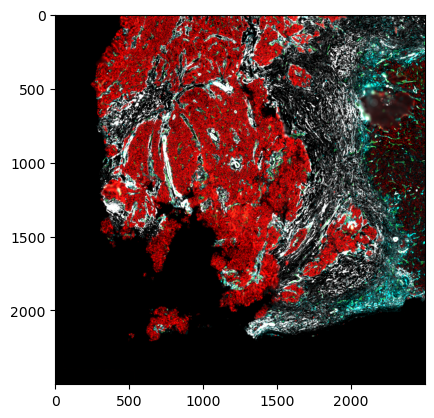

HT413C1-Th1k4A1-U3
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


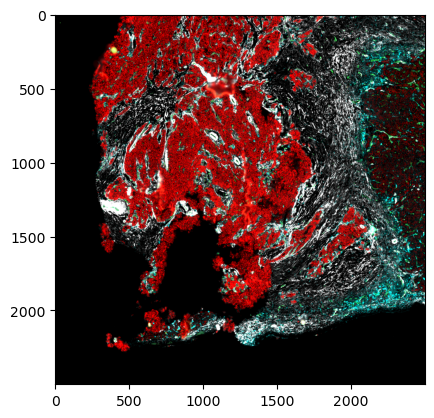

HT413C1-Th1k4A1-U26
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


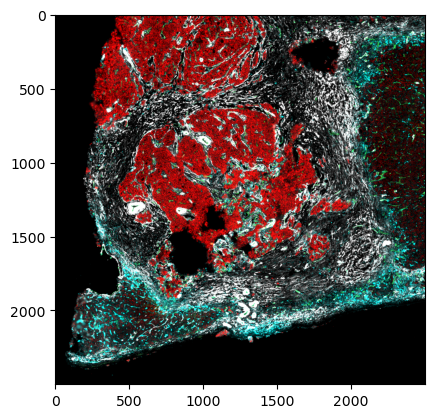

HT413C1-Th1k4A1-U32
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


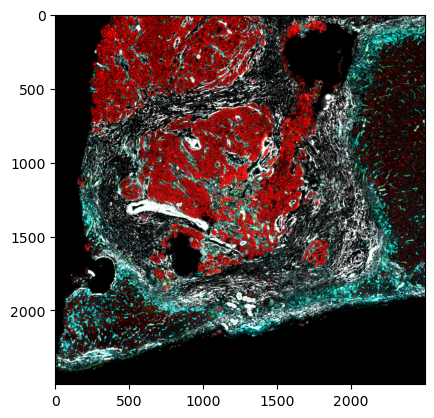

HT413C1-Th1k4A1-U37
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


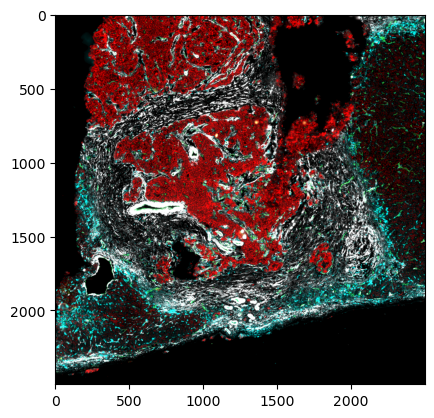

HT413C1-Th1k4A1-U41
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


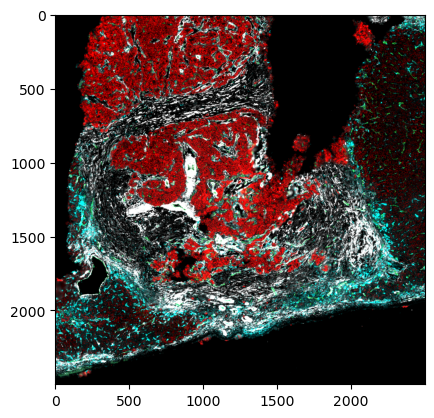

HT413C1-Th1k4A1-U42
dict_keys(['SMA (D)', 'CD31', 'E-cadherin', 'CD68 (D)'])


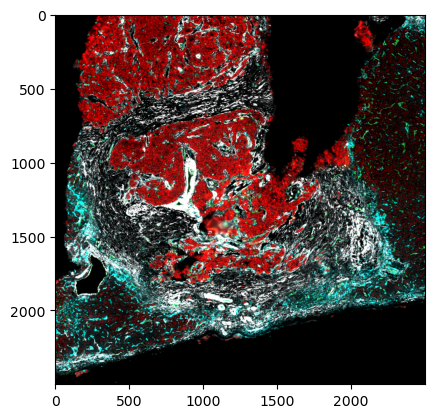

In [50]:
for entry in config['sections']:
    d = entry['data'][0]
    sid = entry['sid']
#     print(d)
    if d['dtype'] == 'multiplex':
        print(sid)
        rgb = get_multiplex_pseudo(d['filepath'], multiplex_view_settings, bbox=bbox)
        plt.imshow(rgb)
        plt.show()
        tifffile.imwrite(output_dir / f'{sid}_rgb.tif', rgb, compression='LZW')

In [66]:
xenium_focus_settings = [
    {
        'channel': 'DAPI',
        'color': 'blue',
        'min_value': 0,
        'max_value': 255,
        'gamma': 1.
    },
#     {
#         'channel': 'ATP1A1/CD45/E-Cadherin',
#         'color': 'magenta',
#         'min_value': 0,
#         'max_value': 100,
#         'gamma': 1.
#     },
#     {
#         'channel': '18S',
#         'color': 'yellow',
#         'min_value': 0,
#         'max_value': 50,
#         'gamma': 1.
#     },
#                          {
#         'channel': 'alphaSMA/Vimentin',
#         'color': 'green',
#         'min_value': 0,
#         'max_value': 100,
#         'gamma': 1.
#     },
]

xenium_view_settings = [
    {
        'channel': 'EPCAM',
        'color': 'red',
        'marker': '.',
    },
    {
        'channel': 'ACTA2',
        'color': 'white',
        'marker': '.',
    },
    {
        'channel': 'PECAM1',
        'color': 'limegreen',
        'marker': '.',
    },
    {
        'channel': 'CD68',
        'color': 'cyan',
        'marker': '.',
    },
]

In [67]:
entry = [x for x in config['sections'] if x['data'][0]['dtype'] == 'xenium'][0]
fp = entry['data'][0]['filepath'].replace('.h5ad', '_morphologyfocus.ome.tiff')
model = from_tiff(fp)
sorted([x.name for x in model.images[0].pixels.channels])

['DAPI']

In [68]:
def get_xenium_pseudo(morph_fp, focus_settings):
    model = from_tiff(morph_fp)
    cs = [x.name for x in model.images[0].pixels.channels]
    if len(cs) == 1: # just nuclei
        channels = ['DAPI']
        colors = ['white']
        min_values = [0.]
        max_values = [100.]
        gammas = [1.]
    else: # multiple channels
        channels = [x['channel'] for x in focus_settings]
        colors = [x['color'] for x in focus_settings]
        min_values = [x['min_value'] for x in focus_settings]
        max_values = [x['max_value'] for x in focus_settings]
        gammas = [x['gamma'] for x in focus_settings]
    
    channel_to_img = extract_ome_tiff(morph_fp, channels=cs, as_dict=True)
    data = np.stack([channel_to_img[x] for x in channels])
    
    rgb = to_pseudocolor(
        data,
        colors=colors,
        min_values=min_values,
        max_values=max_values,
        gammas=gammas
    )
    
    rgb *= 255.
    rgb = rgb.astype(np.uint8)
    
    return rgb

def plot_xenium_pseudo(ax, rgb, transcripts, view_settings, s=.1):
    ax.imshow(rgb)
    
    if not isinstance(transcripts, pd.DataFrame):
        transcripts = pd.read_parquet(transcripts)
        
    pool = set(transcripts['feature_name'])
    for entry in view_settings:
        color = np.asarray(Color(entry['color']).as_rgb_tuple()) / 255.
        channel = entry['channel']
        marker = entry['marker']
        
        if channel in pool:
            small = transcripts[transcripts['feature_name']==channel]
            X = small[['y_location', 'x_location']].values.astype(int)
            ax.scatter(X[:, 1], X[:, 0], color=color, s=s, marker=marker, edgecolors='none')
    return ax

def add_transcripts_to_rgb(rgb, transcripts, xenium_view_settings, pt_scaler=50):
    if not isinstance(transcripts, pd.DataFrame):
        transcripts = pd.read_parquet(transcripts)

    size = (rgb.shape[1] / 1000, rgb.shape[0] / 1000)
    fig, ax = plt.subplots(figsize=(rgb.shape[1] / 1000, rgb.shape[0] / 1000))
    ax.set_axis_off()
    ax = plot_xenium_pseudo(ax, rgb, transcripts, xenium_view_settings, s=size[0] / pt_scaler)
    plt.savefig('temp.tif', bbox_inches='tight', pad_inches=0, dpi=int(1000 * 1.2987411728584588))
    plt.close()
    rgb = tifffile.imread('temp.tif')
    os.remove('temp.tif')
    
    if rgb.shape[-1] == 4:
        rgb = rgb[..., :-1]
    
    return rgb



HT413C1-Th1k4A1-U19


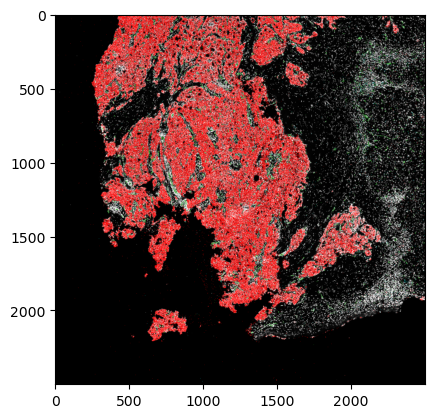

HT413C1-Th1k4A1-U2


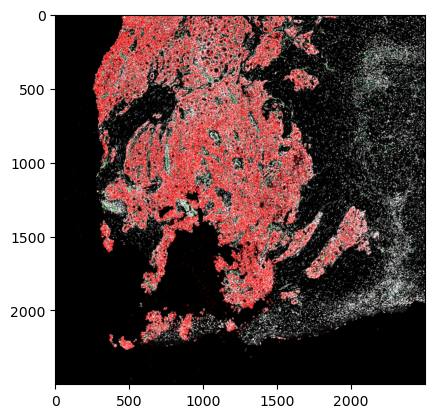

HT413C1-Th1k4A1-U9


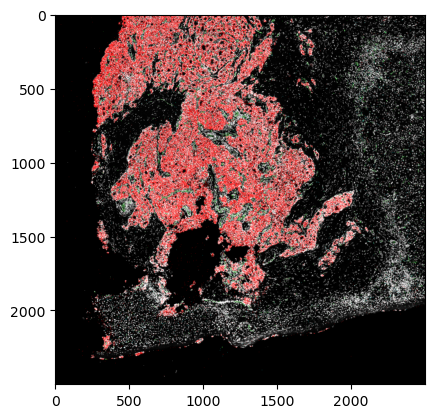

HT413C1-Th1k4A1-U25


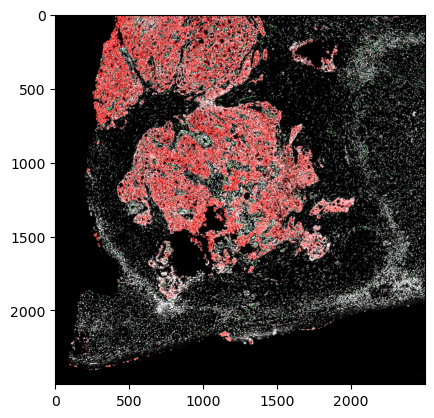

HT413C1-Th1k4A1-U31


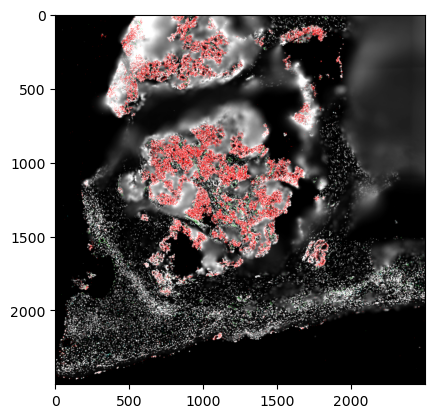

HT413C1-Th1k4A1-U36


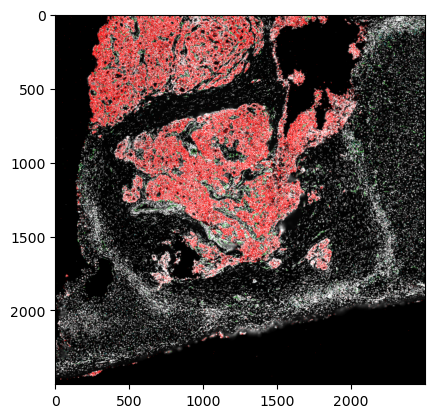

In [69]:
for entry in config['sections']:
    sid = entry['sid']
    d = entry['data'][0]
    if d['dtype'] == 'xenium':
        print(sid)
        fp = d['filepath']
        transcripts_fp = fp.replace('.h5ad', '_transcripts.parquet')
        morph_fp = fp.replace('.h5ad', '_morphologyfocus.ome.tiff')
        assert Path(transcripts_fp).exists()
        assert Path(morph_fp).exists()
        rgb = get_xenium_pseudo(
            morph_fp,
            xenium_focus_settings
        )
        rgb = add_transcripts_to_rgb(
            rgb, transcripts_fp,
            xenium_view_settings
        )
        if bbox is not None:
            r1, r2, c1, c2 = bbox
            rgb = rgb[r1:r2, c1:c2]

        plt.imshow(rgb)
        plt.show()
        
        tifffile.imwrite(output_dir / f'{sid}_rgb.tif', rgb, compression='LZW')

In [70]:
entry = [x for x in config['sections'] if 'he' in x['data'][0]['dtype']][0]
fp = entry['data'][0]['filepath']
fp

'/storage1/fs1/dinglab/Active/Projects/estorrs/mushroom_data_backup/HT413C1-Th1k4A1/registered/s0_HT413C1-Th1k4A1-U14_he.tif'

In [73]:
for entry in config['sections']:
    sid = entry['sid']
    d = entry['data'][0]
    if 'he' in d['dtype']:
        print(sid)
        rgb = tifffile.imread(d['filepath'])
        rgb = rearrange(rgb, 'c h w -> h w c')
        if bbox is not None:
            r1, r2, c1, c2 = bbox
            rgb = rgb[r1:r2, c1:c2]

        tifffile.imwrite(output_dir / f'{sid}_rgb.tif', rgb, compression='LZW')

HT413C1-Th1k4A1-U14
HT413C1-Th1k4A1-U18
HT413C1-Th1k4A1-U1
HT413C1-Th1k4A1-U4
HT413C1-Th1k4A1-U8
HT413C1-Th1k4A1-U11
HT413C1-Th1k4A1-U21
HT413C1-Th1k4A1-U24
HT413C1-Th1k4A1-U27
HT413C1-Th1k4A1-U29
HT413C1-Th1k4A1-U30
HT413C1-Th1k4A1-U35
HT413C1-Th1k4A1-U38
HT413C1-Th1k4A1-U40


In [114]:
data = []
positions = []
for entry in config['sections']:
    sid = entry['sid']
    path = output_dir / f'{sid}_rgb.tif'
    if path.is_file():
        print(sid)
        data.append(tifffile.imread(path))
        positions.append(entry['position'])
data = np.stack(data)
data.shape

HT413C1-Th1k4A1-U14
HT413C1-Th1k4A1-U18
HT413C1-Th1k4A1-U19
HT413C1-Th1k4A1-U20
HT413C1-Th1k4A1-U1
HT413C1-Th1k4A1-U2
HT413C1-Th1k4A1-U3
HT413C1-Th1k4A1-U4
HT413C1-Th1k4A1-U8
HT413C1-Th1k4A1-U9
HT413C1-Th1k4A1-U11
HT413C1-Th1k4A1-U21
HT413C1-Th1k4A1-U24
HT413C1-Th1k4A1-U25
HT413C1-Th1k4A1-U26
HT413C1-Th1k4A1-U27
HT413C1-Th1k4A1-U29
HT413C1-Th1k4A1-U30
HT413C1-Th1k4A1-U31
HT413C1-Th1k4A1-U32
HT413C1-Th1k4A1-U35
HT413C1-Th1k4A1-U36
HT413C1-Th1k4A1-U37
HT413C1-Th1k4A1-U38
HT413C1-Th1k4A1-U40
HT413C1-Th1k4A1-U41
HT413C1-Th1k4A1-U42


(27, 2500, 2500, 3)

In [80]:
to_save = rearrange(data, 'z h w c -> 1 z c h w')
tifffile.imwrite(output_dir / 'stacked.tif',
                 to_save,
                 shape=to_save.shape,
                 ome=True,
                 compression='LZW',
#                  resolution=(1/X_SIZE, 1/Y_SIZE),
                 metadata={'spacing': 1,
                           'unit': 'um',
#                            'axes': 'XYCZT',
                           'axes': 'TZCYX'
                           })

In [81]:
output_dir / 'stacked.tif'

PosixPath('/storage1/fs1/dinglab/Active/Projects/estorrs/serial_section_analysis/evan_crc/stacked.tif')

In [82]:
## run after annotating

In [87]:
rgb = tifffile.imread(output_dir / 'stacked.tif')
rgb.shape

(27, 3, 2500, 2500)

In [116]:
def load_regions(regions_fp):
    regions = json.load(open(regions_fp))['features']
    coords = []
    for x in regions:
        try:
            coords.append(np.asarray(x['geometry']['coordinates']))
        except ValueError:
            print(x['id'], 'failed')
            coords.append(None)
#             raise RuntimeError('failed')
    
    regions = [{
        'id': x['id'],
        'z': x['geometry']['plane']['z'] if 'plane' in x['geometry'] else 0,
        'coordinates': coords[i]
    } for i, x in enumerate(regions) if coords[i] is not None]
    regions = [x for x in regions if len(x['coordinates'].shape) == 3]
    for x in regions:
        x['coordinates'] = x['coordinates'][0][:, [1, 0]]
        x['mask'] = skimage.draw.polygon2mask(rgb.shape[-2:], x['coordinates'])
        x['position'] = positions[x['z']]

    return regions

In [117]:
data = json.load(open(output_dir / 'stacked_annotations.geojson'))
regions = load_regions(output_dir / 'stacked_annotations.geojson')

len(regions), regions[0].keys()

8de8fe4c-50d1-4aaf-bf3e-cdd9141f429a failed
519c9801-ebbb-4b1b-bc8f-d8e551a56768 failed
bf6fd441-8aa0-415c-9b14-ed147f6ee094 failed
b9760ff7-909e-4c85-a6ae-79f6b5f03a8e failed
8923df55-ffb5-4417-a64e-298c27b9fe3f failed
c737b739-13d3-4d45-8846-51bcd0029eee failed
0d02abbf-6239-486c-81b2-14a76d4f221e failed
40534959-e2e0-4fbb-854a-24603a9a7a58 failed
8f1028f6-3feb-4162-9bc2-e0e1ca961696 failed
b92d3f49-9a68-4f57-9ceb-eaf5ef65a4dc failed
752ae3b4-6f12-48e0-90ba-083cec96297b failed
d9a0a50b-5b8e-40c7-9f54-0aadc5e9fae0 failed
1dab1476-e8f3-47d2-96da-fbc0a9a89c4c failed
5a85c4fb-8c49-4acf-a286-29889d0ca5ee failed
370a7d38-318a-4b47-8934-44a76b93b711 failed
f59c8e0e-36f4-42ea-89ab-57bcd5fe39b2 failed
22bbff11-b276-4fb2-b090-5b99c2e4551b failed
f93fb5a7-e24e-485c-84cd-fa4be8c5592a failed
a0cf6c20-54eb-4d21-8f3a-bdcbd8ec7d4e failed
054000c3-9a3a-40a3-ac25-36a40eca04d2 failed
c2418a0d-8d2d-4dd5-a799-098e093936c4 failed
687212d0-bb2e-49a9-862f-b69a0cb217a6 failed
657f0b23-0828-480c-bfac-168e8677

(12790, dict_keys(['id', 'z', 'coordinates', 'mask', 'position']))

In [135]:
regions = sorted(regions, key=lambda x: x['z'])
# regions = sorted(regions, key=lambda x: -x['z'])

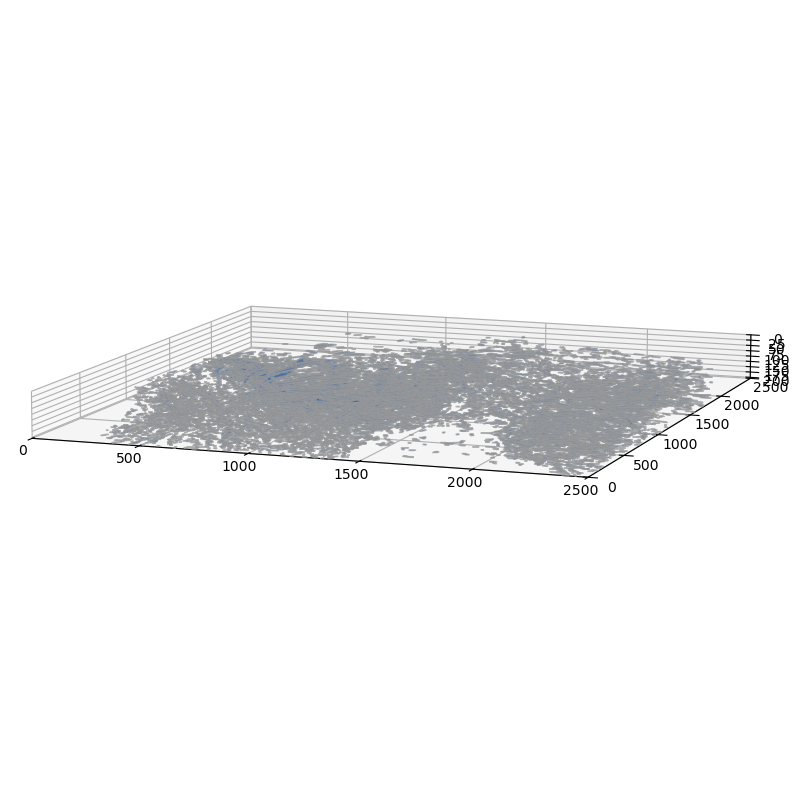

In [154]:
elev, azim = 10, 290

ax = plt.figure(figsize=(10, 10)).add_subplot(projection='3d')

coords = [np.asarray(x['coordinates'])[:, [1, 0]] for x in regions]

zs = [x['position'] for x in regions]
facecolors = [(0.19607843, 0.38431373, 0.65882353, 1.) for i in range(len(zs))]
poly = PolyCollection(coords, facecolors=facecolors, alpha=.7, edgecolor=(.6, .6, .6, .1))

ax.set(xlim=(0, rgb.shape[-2]), ylim=(0, rgb.shape[-1]), zlim=(0, max(zs)), aspect='equal')
ax.add_collection3d(poly, zs=zs, zdir='z')
ax.view_init(elev=elev, azim=azim)
ax.invert_zaxis()
ax.set_aspect('equal')
# plt.show()
plt.savefig(output_dir / f'annotated_regions_elev{elev}_azim{azim}.png', dpi=300)

In [155]:
output_dir

PosixPath('/storage1/fs1/dinglab/Active/Projects/estorrs/serial_section_analysis/evan_crc')